# A permissive winning-region shield for a tiny RL agent

This live demo follows the delivery-robot example from the MODeM 2026 talk:
the environment supplies `request` and `blocked`; the controller chooses
`serve` and `recharge`.

The experiment is deliberately pedagogical, not an Acacia-Bonsai benchmark.
The Boolean closest-correction rule below uses Hamming distance.  It is an
analogue of—rather than identical to—the $\mathcal T_\mathbb Z$ optimisation
$\min |y-y'|$ in Rodríguez, Amir, Corsi, Sánchez & Katz (AAAI 2025).

## 1. Make the missing assumption explicit

Acacia receives the **negated** specification and constructs a universal
co-Büchi automaton for bad plays.  The guarantees conflict if `blocked` may
remain true forever.  Assuming the route is unblocked infinitely often restores
realizability.

In [1]:
import itertools
import math
import random

import acacia_boomslang as ab


INPUTS = ["request", "blocked"]
OUTPUTS = ["serve", "recharge"]
ACTIONS = list(itertools.product([False, True], repeat=len(OUTPUTS)))
BARE = (
    "G(blocked -> !serve) & "
    "G(request -> F serve) & "
    "G F recharge"
)
ASSUMED = f"(G F !blocked) -> ({BARE})"


def negated(formula):
    return f"!({formula})"


def bits_label(bits, names):
    selected = [name for name, bit in zip(names, bits) if bit]
    return "+".join(selected) if selected else "idle"


def vector_values(vector):
    # Index explicitly: the SWIG sequence iterator in 2.0.15 is less robust
    # than its indexed interface.
    return tuple(vector[index] for index in range(len(vector)))


def antichain_heads(region):
    heads = []
    for head in region:
        values = []
        for index in range(len(head)):
            values.append(head[index])
        heads.append(values)
    return heads


def build_game(formula, k_max, k_min=None):
    game = ab.create_twa(negated(formula), INPUTS, OUTPUTS)
    ab.preprocess_aut_standard(game, k_max=k_max)
    ab.set_bool_thresh_no_bool_states(game, k_max=k_max)
    if k_min is None:
        k_min = min(2, k_max)
    result = ab.solve_acacia_safety_game(
        game, k_max=k_max, k_min=k_min, k_inc=1
    )
    return game, result


class Shield:
    """Winning-region action filter for the two Boolean output APs."""

    def __init__(self, game, result):
        if not result.is_real():
            raise ValueError("a shield requires a realizable game")
        self.game = game
        self.result = result  # Keep the native owner alive.
        self.region = result.get_winning_region()
        self.k = self.region.k()

    def initial(self):
        return ab.get_initial_state(self.game)

    def successor(self, state_vector, env_input, output):
        true_aps = [
            ap
            for ap, bit in zip(INPUTS + OUTPUTS, env_input + output)
            if bit
        ]
        false_aps = [
            ap
            for ap, bit in zip(INPUTS + OUTPUTS, env_input + output)
            if not bit
        ]
        return ab.successor(
            self.game,
            state_vector,
            ab.StringVector(true_aps),
            ab.StringVector(false_aps),
            self.k,
        )

    def allowed(self, state_vector, env_input):
        options = []
        for output in ACTIONS:
            next_vector = self.successor(state_vector, env_input, output)
            if self.region.contains(next_vector):
                options.append((output, next_vector))
        return options

    def choose(self, state_vector, env_input, proposal, mode="permissive"):
        options = self.allowed(state_vector, env_input)
        if not options:
            raise RuntimeError("no winning output from a state in the winning region")
        if mode == "intrusive":
            # A fixed controller commits to the first certified output.
            chosen, next_vector = options[0]
        elif mode == "permissive":
            # Boolean analogue of min |y-y'|: minimise Hamming correction.
            chosen, next_vector = min(
                options,
                key=lambda item: (
                    sum(a != b for a, b in zip(item[0], proposal)),
                    ACTIONS.index(item[0]),
                ),
            )
        else:
            raise ValueError(mode)
        return chosen, next_vector, chosen != proposal


In [2]:
unreal_game, unreal_result = build_game(BARE, k_max=8)
real_game, real_result = build_game(ASSUMED, k_max=2, k_min=2)
shield = Shield(real_game, real_result)

print("Without assumption: realizable =", unreal_result.is_real())
print("With GF !blocked: realizable =", real_result.is_real())
print("UCB states =", ab.num_states(real_game))
print("winning k =", shield.k)
print("antichain maxima =", len(shield.region), antichain_heads(shield.region))

initial = shield.initial()
for env_input in [(False, False), (True, False), (False, True), (True, True)]:
    allowed = [output for output, _ in shield.allowed(initial, env_input)]
    print(
        f"input {bits_label(env_input, INPUTS):>15}: ",
        [bits_label(output, OUTPUTS) for output in allowed],
    )


Without assumption: realizable = False
With GF !blocked: realizable = True
UCB states = 7
winning k = 2
antichain maxima = 1 [[0, -1, 1, 1, -1, 1, 1]]
input            idle:  ['idle', 'recharge', 'serve', 'serve+recharge']
input         request:  ['idle', 'recharge', 'serve', 'serve+recharge']
input         blocked:  ['idle', 'recharge']
input request+blocked:  ['idle', 'recharge']


## 2. Compare a fixed-controller shield with a permissive shield

`Shield.allowed(state, input)` exposes every output whose successor is still in
the winning region.  The intrusive mode always follows one fixed certified
choice.  The permissive mode preserves a safe proposal, and otherwise makes the
smallest Boolean correction.

In [3]:
def compare_modes(mode, proposals, environment_inputs):
    state_vector = shield.initial()
    interventions = 0
    for proposal, env_input in zip(proposals, environment_inputs):
        _, state_vector, changed = shield.choose(
            state_vector, env_input, proposal, mode=mode
        )
        interventions += int(changed)
    return interventions


comparison_rng = random.Random(11)
proposal_trace = [comparison_rng.choice(ACTIONS) for _ in range(120)]
env_cycle = [(False, False), (True, False), (True, True), (False, True)]
environment_trace = [env_cycle[index % len(env_cycle)] for index in range(120)]

intrusive_count = compare_modes("intrusive", proposal_trace, environment_trace)
permissive_count = compare_modes("permissive", proposal_trace, environment_trace)
print("fixed-controller interventions:", intrusive_count)
print("winning-region interventions:", permissive_count)
assert permissive_count < intrusive_count


fixed-controller interventions: 86
winning-region interventions: 43


## 3. Learn behind the envelope

The tiny exogenous MDP emits requests stochastically and never keeps the route
blocked for two consecutive steps, so it satisfies the environment assumption.
The reward values throughput enough to tempt an unshielded learner to serve
while blocked.  Both runs use the same seeded environment traces.

In [4]:
class RobotEnvironment:
    """Tiny exogenous MDP over request/blocked; blocked never persists."""

    def __init__(self, seed):
        self.rng = random.Random(seed)
        self.was_blocked = False

    def reset(self):
        self.was_blocked = False
        return self.observe()

    def observe(self):
        request = self.rng.random() < 0.55
        blocked = False if self.was_blocked else self.rng.random() < 0.38
        self.was_blocked = blocked
        return request, blocked


def task_reward(env_input, output):
    request, blocked = env_input
    serve, recharge = output
    reward = 0.0
    if serve:
        reward += 1.4  # throughput bonus tempts serving even while blocked
    if request and serve:
        reward += 3.0
    if recharge:
        reward -= 0.25
    if request and not serve:
        reward -= 0.35
    return reward


def train(seed, use_shield, episodes=180, horizon=24):
    rng = random.Random(seed)
    q = {state: [0.0] * len(ACTIONS) for state in ACTIONS}
    episode_reward = []
    episode_violations = []
    episode_interventions = []

    for episode in range(episodes):
        env = RobotEnvironment(seed * 10000 + episode)
        env_input = env.reset()
        state_vector = shield.initial() if use_shield else None
        total_reward = violations = interventions = 0
        epsilon = max(0.03, 0.35 * (1 - episode / episodes))

        for _ in range(horizon):
            if rng.random() < epsilon:
                proposal_index = rng.randrange(len(ACTIONS))
            else:
                values = q[env_input]
                proposal_index = max(range(len(ACTIONS)), key=values.__getitem__)
            proposal = ACTIONS[proposal_index]

            if use_shield:
                executed, state_vector, changed = shield.choose(
                    state_vector, env_input, proposal, mode="permissive"
                )
            else:
                executed, changed = proposal, False

            reward = task_reward(env_input, executed) - 1.0 * int(changed)
            violation = env_input[1] and executed[0]
            next_input = env.observe()

            old = q[env_input][proposal_index]
            target = reward + 0.92 * max(q[next_input])
            q[env_input][proposal_index] = old + 0.22 * (target - old)

            total_reward += reward
            violations += int(violation)
            interventions += int(changed)
            env_input = next_input

        episode_reward.append(total_reward)
        episode_violations.append(violations)
        episode_interventions.append(interventions)

    return {
        "reward": episode_reward,
        "violations": episode_violations,
        "interventions": episode_interventions,
        "q": q,
    }


In [5]:
unshielded = train(seed=23, use_shield=False)
shielded = train(seed=23, use_shield=True)

print("unshielded safety violations:", sum(unshielded["violations"]))
print("shielded safety violations:", sum(shielded["violations"]))
print("shield interventions:", sum(shielded["interventions"]))
print(
    "mean reward, final 30 episodes:",
    round(sum(unshielded["reward"][-30:]) / 30, 2),
    "unshielded /",
    round(sum(shielded["reward"][-30:]) / 30, 2),
    "shielded",
)
assert sum(unshielded["violations"]) > 0
assert sum(shielded["violations"]) == 0


unshielded safety violations: 1105
shielded safety violations: 0
shield interventions: 744
mean reward, final 30 episodes: 70.95 unshielded / 43.11 shielded


The shielded run has zero observed safety violations.  Its lower return is not a
performance claim: the unshielded reward intentionally pays for the forbidden
shortcut.  The point is that learning continues over the outputs that remain in
the certified envelope.

inline SVG bytes: 5045


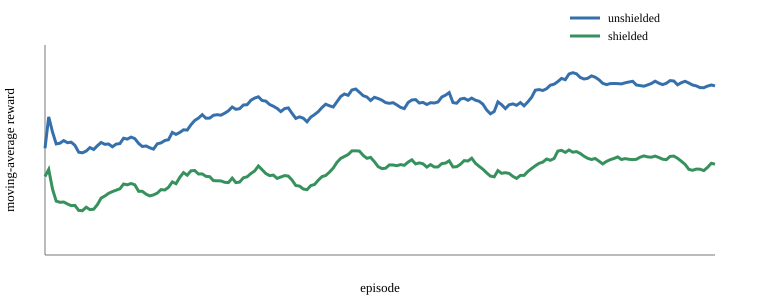

In [6]:
class LearningPlot:
    """Dependency-free inline SVG plot for a Jupyter output cell."""

    def __init__(self, series):
        self.series = series

    def _repr_svg_(self):
        width, height, pad = 760, 300, 45
        flattened = [value for _, values, _ in self.series for value in values]
        low, high = min(flattened), max(flattened)
        span = max(1.0, high - low)
        chunks = [
            f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">',
            '<rect width="100%" height="100%" fill="white"/>',
            f'<line x1="{pad}" y1="{height-pad}" x2="{width-pad}" y2="{height-pad}" stroke="#777"/>',
            f'<line x1="{pad}" y1="{pad}" x2="{pad}" y2="{height-pad}" stroke="#777"/>',
            '<text x="380" y="292" text-anchor="middle" font-size="13">episode</text>',
            '<text x="14" y="150" text-anchor="middle" font-size="13" transform="rotate(-90 14 150)">moving-average reward</text>',
        ]
        for series_index, (name, values, colour) in enumerate(self.series):
            smooth = []
            for index in range(len(values)):
                window = values[max(0, index - 11) : index + 1]
                smooth.append(sum(window) / len(window))
            points = []
            for index, value in enumerate(smooth):
                x = pad + index * (width - 2 * pad) / max(1, len(smooth) - 1)
                y = height - pad - (value - low) * (height - 2 * pad) / span
                points.append(f"{x:.1f},{y:.1f}")
            chunks.append(
                f'<polyline fill="none" stroke="{colour}" stroke-width="3" points="{" ".join(points)}"/>'
            )
            legend_y = 18 + 18 * series_index
            chunks.append(
                f'<line x1="570" y1="{legend_y}" x2="600" y2="{legend_y}" stroke="{colour}" stroke-width="3"/>'
                f'<text x="608" y="{legend_y + 4}" font-size="12">{name}</text>'
            )
        chunks.append("</svg>")
        return "".join(chunks)


learning_plot = LearningPlot(
    [
        ("unshielded", unshielded["reward"], "#3570ac"),
        ("shielded", shielded["reward"], "#36915d"),
    ]
)
svg = learning_plot._repr_svg_()
assert svg.startswith("<svg") and "polyline" in svg
print("inline SVG bytes:", len(svg))

learning_plot


## 4. Grow the certified envelope

For this example, the first realizable bound is $k=2$.  Solving at $k=4$ raises
the antichain maximum.  After one idle step, the smaller approximation insists
on recharging next; the larger one certifies all four outputs.  These are
computed values, not staged labels.

In [7]:
game_k4, result_k4 = build_game(ASSUMED, k_max=4, k_min=4)
shield_k4 = Shield(game_k4, result_k4)
idle_input = (False, False)
idle_output = (False, False)
state_k2 = shield.successor(shield.initial(), idle_input, idle_output)
state_k4 = shield_k4.successor(shield_k4.initial(), idle_input, idle_output)
allowed_k2 = [output for output, _ in shield.allowed(state_k2, idle_input)]
allowed_k4 = [output for output, _ in shield_k4.allowed(state_k4, idle_input)]

print("k=2 antichain:", antichain_heads(shield.region))
print("k=4 antichain:", antichain_heads(shield_k4.region))
print("after one idle step, k=2 allows:", allowed_k2)
print("after one idle step, k=4 allows:", allowed_k4)
assert len(allowed_k2) == 2
assert len(allowed_k4) == 4


k=2 antichain: [[0, -1, 1, 1, -1, 1, 1]]
k=4 antichain: [[2, -1, 3, 3, -1, 3, 3]]
after one idle step, k=2 allows: [(False, True), (True, True)]
after one idle step, k=4 allows: [(False, False), (False, True), (True, False), (True, True)]


### Takeaway

The synthesized object is an action envelope.  The specification establishes
the boundary; the learner ranks choices inside it.